# Proyecto de Estadística Multivariada
# Our World in Data CO2 and Greenhouse Gas Emissions dataset

## Librerías

In [854]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import optuna
from pandas.plotting import andrews_curves,parallel_coordinates,radviz

from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score

## Exploración general de los datos

In [855]:
df = pd.read_csv("/home/ara/Downloads/owid-co2-data.csv")

In [856]:
df.shape

(50411, 79)

In [857]:
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [858]:
df.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,...,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017453e+07,3.300495e+11,7.890109,0.060013,420.227035,6.268847,42.598225,544.144592,7.483698,...,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308433e+08,3.086383e+12,62.988171,0.123562,1972.092032,62.199548,1721.913018,2273.281696,99.512520,...,17.448980,9.282343,0.015362,0.045687,0.062888,0.003048,2414.076755,1812.363570,259.018184,62.637598
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,...,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000,-2177.807000,-98.281000
25%,1875.000000,3.272140e+05,7.874038e+09,0.000000,0.000000,0.381000,-0.005000,-1.070500,6.667750,-0.727500,...,0.144000,0.003000,0.000000,0.000000,0.000000,0.000000,1.502000,0.221000,-2.262250,-6.828750
50%,1925.000000,2.291594e+06,2.743861e+10,0.000000,0.001000,5.081000,0.044000,3.813000,28.120000,0.112000,...,0.588500,0.081000,0.000000,0.000000,0.000000,0.000000,14.605500,2.222000,1.641000,8.381500
75%,1975.000000,9.986553e+06,1.212627e+11,0.524000,0.076250,53.656500,1.018000,10.884000,124.303250,2.765250,...,2.416500,0.373000,0.000000,0.001000,0.002000,0.000000,76.508500,27.863000,11.425500,32.782250
max,2024.000000,8.161973e+09,1.301126e+14,1666.885000,2.484000,38598.578000,1804.657000,180870.000000,43184.086000,2614.874000,...,100.000000,100.000000,0.377000,1.216000,1.678000,0.085000,54433.398000,43714.777000,1768.846000,1023.042000


In [859]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

Países únicos

In [860]:
df['country'].unique()

array(['Afghanistan', 'Africa', 'Africa (GCP)', 'Albania', 'Algeria',
       'Andorra', 'Angola', 'Anguilla', 'Antarctica',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia',
       'Asia (GCP)', 'Asia (excl. China and India)', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda',
       'Bhutan', 'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Central African Republic', 'Central America (GCP)', 'Chad',
       'Chile', 'China', 'Christmas Island', 'Colombia', 'Comoros',
       'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia',
       'Cuba', 'Curacao', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Domini

## Limpieza del dataset

Esta función acota y filtra el DataFrame para su análisis posterior.  Elimina datos incompletos o nulos, filtrando primero por `min_year` para enfocarse en períodos con datos más consistentes. Además excluye países o entidades agregadas (`countries_to_exclude`) que podrían distorsionar el análisis a nivel países.  Elimina las columnas con un porcentaje de valores nulos superior a `max_null_percentage`, para evitar trabajar con datos demasiado dispersos. Finalmente asegura que columnas esenciales como 'country', 'year' y 'co2' siempre estén presentes, incluso si no cumplen el criterio de `max_null_percentage`, para tener un conjunto de datos más manejable.

In [861]:
def limpieza(df, min_year, max_null_percentage, countries_to_exclude=None):
  """
    Limpia y acota el dataset según múltiples criterios.
  """

  # Filtrar por año
  df_clean = df[df["year"] >= min_year].copy()

  # Filtrar por países individuales
  if countries_to_exclude:
    df_clean = df_clean[~df_clean["country"].isin(countries_to_exclude)]

  # Porcentaje de valores nulos por columna
  values = (df_clean.isnull().sum() / len(df_clean)) * 100

  # Seleccionar columnas con suficientes datos
  good_cols = values[values <= max_null_percentage].index.tolist()

  # Seleccionar campos esenciales, incluyendo 'energy_per_capita' para el radar chart
  # y otras variables usadas en la matriz de correlación y MLR
  essential_cols = ["country", "year", "iso_code", "population", "co2", "gdp",
                    "co2_per_gdp", "coal_co2", "oil_co2", "gas_co2",
                    "cement_co2", "energy_per_capita", "co2_per_capita",
                    "total_ghg", "cumulative_co2", "share_global_co2"]
  for col in essential_cols:
    if col not in good_cols and col in df_clean.columns:
      good_cols.append(col)

  # Df ya limpio
  df_final = df_clean[good_cols].copy()

  print(f"Total de registros {len(df_final)} de {len(df)}")
  print(f"Columnas finales {df_final.columns}")
  return df_final

In [862]:
countries_to_exclude = [
    'World', 'Africa', 'Africa (GCP)', 'Asia', 'Asia (GCP)',
    'Asia (excl. China and India)', 'Central America (GCP)', 'Europe',
    'Europe (GCP)', 'Europe (excl. EU-27)', 'Europe (excl. EU-28)',
    'European Union (27)', 'European Union (28)', 'High-income countries',
    'International aviation', 'International shipping', 'Least developed countries (Jones et al.)',
    'Low-income countries', 'Lower-middle-income countries', 'Middle East (GCP)',
    'Non-OECD (GCP)', 'North America', 'North America (GCP)',
    'North America (excl. USA)', 'OECD (GCP)', 'OECD (Jones et al.)',
    'Oceania', 'Oceania (GCP)', 'Ryukyu Islands (GCP)', 'South America',
    'South America (GCP)', 'Upper-middle-income countries', 'Kuwaiti Oil Fires (GCP)',
    'Kuwaiti Oil Fires', 'Ryukyu Islands'
]

Aplicamos la limpieza

In [863]:
df_clean = limpieza(
    df,
    min_year=1950,
    max_null_percentage=10,
    countries_to_exclude= countries_to_exclude
)

Total de registros 16425 de 50411
Columnas finales Index(['country', 'year', 'iso_code', 'population', 'cement_co2', 'co2',
       'co2_growth_abs', 'co2_growth_prct', 'co2_per_capita',
       'cumulative_cement_co2', 'cumulative_co2', 'cumulative_oil_co2',
       'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'methane',
       'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_per_capita',
       'oil_co2', 'oil_co2_per_capita', 'share_global_cement_co2',
       'share_global_co2', 'share_global_cumulative_cement_co2',
       'share_global_cumulative_co2', 'share_global_cumulative_oil_co2',
       'share_global_oil_co2', 'share_of_temperature_change_from_ghg',
       'temperature_change_from_ch4', 'temperature_change_from_co2',
       'temperature_change_from_ghg', 'temperature_change_from_n2o',
       'total_ghg', 'total_ghg_excluding_lucf', 'gdp', 'co2_per_gdp',
       'coal_co2', 'gas_co2', 'energy_per_capita'],
      dtype='object')


Ya que siguen siendo bastantes columnas para fines de este análisis, de las columnas resultantes extraemos las columnas más relevantes para quedarnos con al menos 5 variables categóricas y 5 numéricas.  

In [864]:
def select_columns(df):
    """
    Selecciona las columnas más relevantes para análisis
    """

    columns = [
        'country', 'year', 'iso_code',           # Identificadores
        'population', 'gdp',                     # Economía
        'co2', 'co2_per_capita', 'total_ghg',    # Emisiones
        'coal_co2', 'oil_co2', 'gas_co2',        # Por fuente energética
        'cement_co2' ,
        'co2_per_gdp',                           # Intensidad carbono-PIB
        'energy_per_capita' ,
        'cumulative_co2',
        'share_global_co2'
    ]

    # Filtrar las columnas que existen en el df actual y que están en nuestra lista de columnas.
    selected_cols = [col for col in columns if col in df.columns]

    return df[selected_cols]

In [865]:
df_c = select_columns(df_clean)
df_c.shape

(16425, 16)

Después de seleccionar las columnas más importantes tenemos:

- Categóricas: 3 variables (country, iso_code, year)
- Numéricas: 13 variables continuas

Derivamos algunas variables categóricas a partir de otras para completar las 5 variables categóricas

- Nivel de desarrollo per cápita
- Intensidad de emisiones de carbono

In [866]:
df_final = df_c.copy()
# Nivel de desarrollo (PIB per cápita)
df_final['development_level'] = pd.qcut(
    df_final['gdp'] / df_final['population'],
    q=3,
    labels=['Bajo', 'Medio', 'Alto'])

# Intensidad de carbono (alta/media/baja)
df_final['carbon_intensity'] = pd.qcut(
    df_final['co2_per_gdp'],
    q=3,
    labels=['Baja', 'Media', 'Alta'])

In [867]:
df_final.isnull().sum()

country                 0
year                    0
iso_code               75
population            150
gdp                  4968
co2                  1124
co2_per_capita       1207
total_ghg            1500
coal_co2             5893
oil_co2              1232
gas_co2              8418
cement_co2           1514
co2_per_gdp          5188
energy_per_capita    6670
cumulative_co2       1124
share_global_co2     1124
development_level    4968
carbon_intensity     5188
dtype: int64

In [868]:
nan_percent = df_final.isnull().sum() / len(df_final) * 100
nan_percent

country               0.000000
year                  0.000000
iso_code              0.456621
population            0.913242
gdp                  30.246575
co2                   6.843227
co2_per_capita        7.348554
total_ghg             9.132420
coal_co2             35.878234
oil_co2               7.500761
gas_co2              51.251142
cement_co2            9.217656
co2_per_gdp          31.585997
energy_per_capita    40.608828
cumulative_co2        6.843227
share_global_co2      6.843227
development_level    30.246575
carbon_intensity     31.585997
dtype: float64

In [869]:
df_final.shape

(16425, 18)

In [870]:
df_final.describe()

,year,population,gdp,co2,co2_per_capita,total_ghg,coal_co2,oil_co2,gas_co2,cement_co2,co2_per_gdp,energy_per_capita,cumulative_co2,share_global_co2
count,16425.00000,1.627500e+04,1.145700e+04,15301.000000,15218.000000,14925.000000,10532.000000,15193.000000,8007.000000,14911.000000,11237.000000,9755.000000,15301.000000,15301.000000
mean,1987.00000,2.368226e+07,3.074156e+11,103.083848,5.315943,182.366202,62.255767,37.252331,33.977790,3.265109,0.369452,24225.790386,4025.700475,0.476711
std,21.64937,1.005430e+08,1.243808e+12,529.157124,18.402151,696.316471,366.995306,165.581110,125.741913,26.689577,0.865882,32979.011029,21812.590288,2.276432
min,1950.00000,5.010000e+02,4.998000e+07,0.000000,0.000000,-9.219000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1968.00000,4.383095e+05,8.464075e+09,0.520000,0.412000,5.799000,0.029000,0.451000,0.114000,0.000000,0.135000,2560.833000,8.106000,0.003000
50%,1987.00000,3.958735e+06,3.212215e+10,4.842000,1.947500,31.824000,1.282000,2.693000,2.741000,0.158000,0.246000,11342.992000,104.799000,0.023000
75%,2006.00000,1.276279e+07,1.520770e+11,37.601000,6.306000,94.989000,13.306250,17.236000,17.896500,1.192000,0.446000,34082.050500,1030.788000,0.172000
max,2024.00000,1.450936e+09,2.696602e+13,12289.037000,782.743000,14107.007000,8886.021000,2584.130000,1748.138000,828.710000,82.599000,318559.688000,434866.562000,42.855000


In [874]:
df_final.to_csv('data_clean.csv', index=False)


## Plots

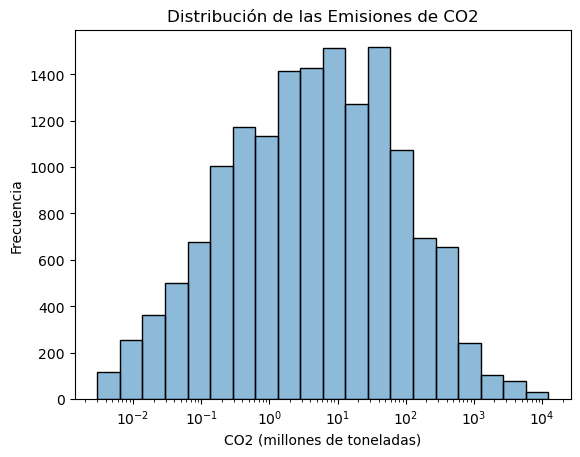

In [871]:
sns.histplot(df_final['co2'], bins=20, kde=True, log_scale = True)
plt.title('Distribución de las Emisiones de CO2')
plt.xlabel('CO2 (millones de toneladas)')
plt.ylabel('Frecuencia')
plt.show()

Este plot nos permite ver claramente que, aunque hay un gran número de países con emisiones relativamente bajas (parte izquierda de la gráfica), la distribución sigue mostrando una tendencia donde las emisiones más altas, aunque menos frecuentes, son significativas. Vemos que la mayoría de los valores son pequeños y unos pocos extremadamente grandes.

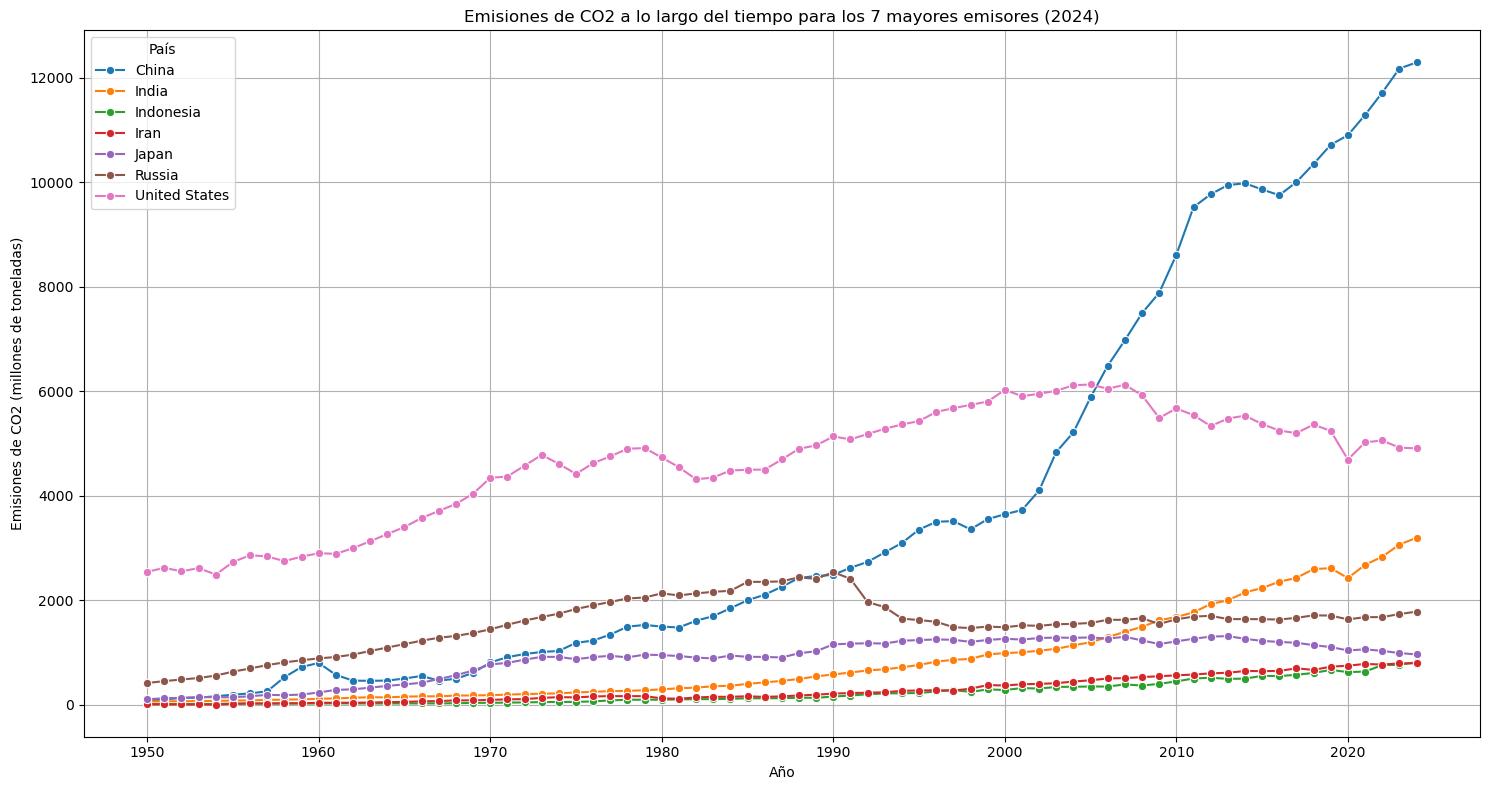

In [845]:
# Países con mayores emisiones en el último año
last_year = df_final['year'].max()
top_emitters = df_final[df_final['year'] == last_year].sort_values(by='co2', ascending=False).head(7)
top_countries = top_emitters['country'].tolist()

# Filtrar el DataFrame para estos países y visualizar las tendencias
top_countries = df_final[df_final['country'].isin(top_countries)]

plt.figure(figsize=(15, 8))
sns.lineplot(data=top_countries, x='year', y='co2', hue='country', marker='o')
plt.title(f'Emisiones de CO2 a lo largo del tiempo para los 7 mayores emisores ({last_year})')
plt.xlabel('Año')
plt.ylabel('Emisiones de CO2 (millones de toneladas)')
plt.grid(True)
plt.legend(title='País')
plt.tight_layout()
plt.show()

En la gráfica se observa que China es el país que más contamina y su tendencia es creciente. Le sigue Estados Unidos, con una tendencia ligeramente decreciente. India es el tercer país con una tendencia creciente. Rusia se ubica en cuarto lugar, con una tendencia ligeramente creciente. Japón es el quinto país, con una tendencia ligeramente decreciente. Finalmente Iran e Indonesia son los últimos países con una tendencia ligeramente creciente.

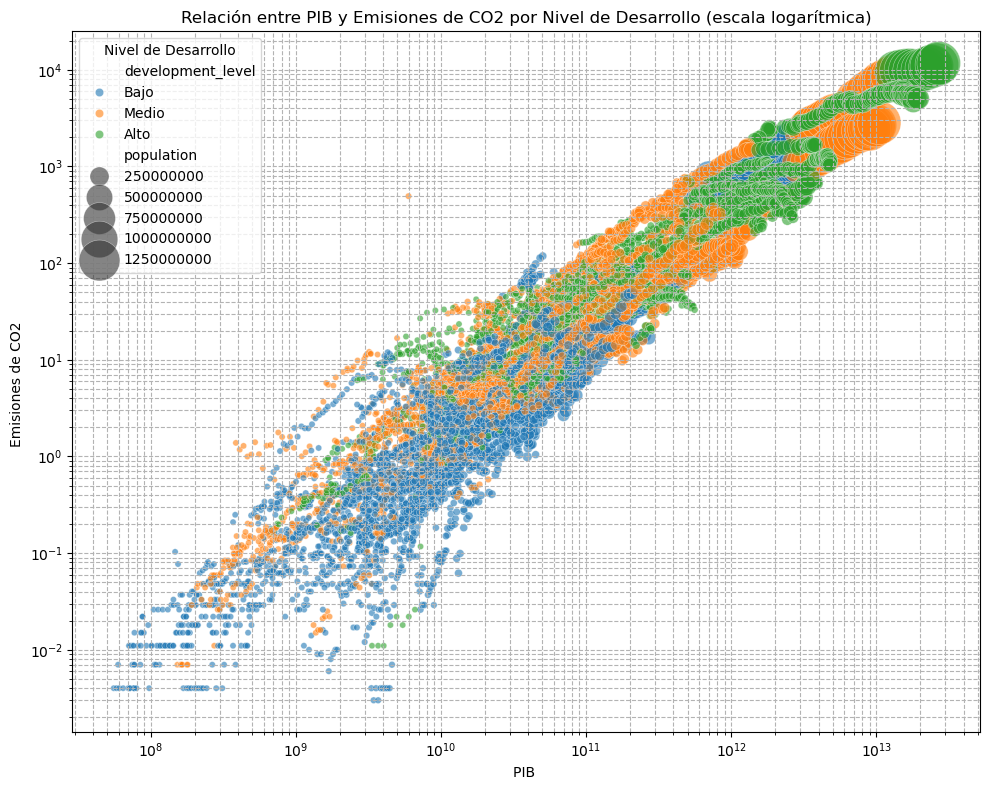

In [846]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_final, x='gdp', y='co2', hue='development_level', size='population', sizes=(20, 1000), alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title('Relación entre PIB y Emisiones de CO2 por Nivel de Desarrollo (escala logarítmica)')
plt.xlabel('PIB ')
plt.ylabel('Emisiones de CO2 ')
plt.grid(True, which='both', ls='--', c='0.7')
plt.legend(title='Nivel de Desarrollo')
plt.tight_layout()
plt.show()

De acuerdo al gráfico se observa una tendencia donde un mayor PIB se asocia con mayores emisiones de CO2; esto es esperable, ya que la actividad económica suele ir de la mano con el consumo de energía y por lo tanto con las emisiones.

Los países con un desarrollo alto tienden a concentrarse en la parte superior derecha del gráfico, indicando un PIB elevado y altas emisiones de CO2, aunque algunos países de alto desarrollo muestran una disminución de CO2, mientras el PIB sigue alto. Los países de nivel medio tienen un rango de emisiones medio-alto y finalmente los países de nivel bajo tienen PIB y emisiones mucho más bajas, aunque unos pocos producen significativamente más emisiones en relación a su PIB.

-El tamaño de los puntos (población) muestra que los países más poblados como China e India contribuyen significativamente al PIB y a las emisiones.

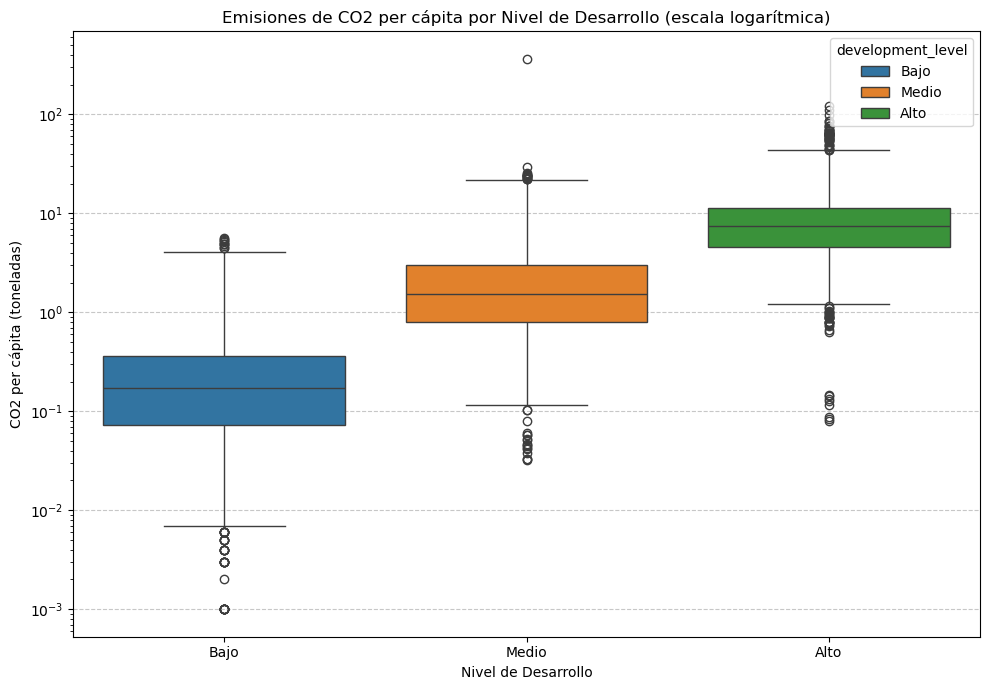

In [847]:
plt.figure(figsize=(10, 7))
sns.boxplot(data=df_final, x='development_level', y='co2_per_capita', hue='development_level', log_scale=True)
plt.title('Emisiones de CO2 per cápita por Nivel de Desarrollo (escala logarítmica)')
plt.xlabel('Nivel de Desarrollo')
plt.ylabel('CO2 per cápita (toneladas)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Con este gráfico comprobamos que hay una relación entre el nivel de desarrollo y las emisiones de CO2 per cápita: a mayor nivel de desarrollo más emisiones de CO2.  Los países con un nivel de desarrollo alto presentan las emisiones de CO2 per cápita más elevadas. Reflejado en una mediana significativamente mayor en comparación con los otros grupos vemos que la caja es más pequeña que la de los otros niveles. Además se observan muchos outliers en cada nivel de desarollo, indicando que algunos países de alto desarrollo tienen emisiones per cápita extremadamente altas y también hay países con emisiones más bajas que los países de nivel de desarrollo medio.

Los países con nivel de desarrollo medio tienen emisiones per cápita mucho menores que los de alto desarrollo, aunque más altas que los de bajo desarrollo (la escala en el eje vertical es logarítmica). La dispersión de estos es menor, aunque tiene bastantes outliers en la parte inferior indicando que una parte de la población de nivel medio emite menos emisiones que su media.

Los países con nivel de desarrollo bajo tienen las emisiones de CO2 per cápita más bajas, con una caja muy cercana a cero y una dispersión mínima. Esto sugiere que, en promedio, los países menos desarrollados tienen una huella de carbono per cápita mucho menor.


In [848]:
# Años únicos ordenados
years_sorted = sorted(df_final['year'].dropna().unique())

# Penúltimo año
valid_year = years_sorted[-3] # En 2024 y 2023 no hay datos válidos. Si hay en 2022
print(valid_year)

df_tmp = df_final[df_final['year'] == valid_year]

df_tmp['development_level'].value_counts(dropna=False)


2022


development_level
Alto     95
NaN      55
Medio    41
Bajo     28
Name: count, dtype: int64

Valores negativos o cero:
       coal_co2  oil_co2
272       3.488    6.528
897       0.542    2.946
1072      0.758   61.610
1347      0.000    0.416
1522        NaN   14.887
...         ...      ...
49334   177.248   72.805
49508       NaN    0.029
49958     0.256    7.952
50133     5.082    4.977
50408     7.165    4.679

[219 rows x 2 columns]
coal_co2    9
oil_co2     0
dtype: int64
---


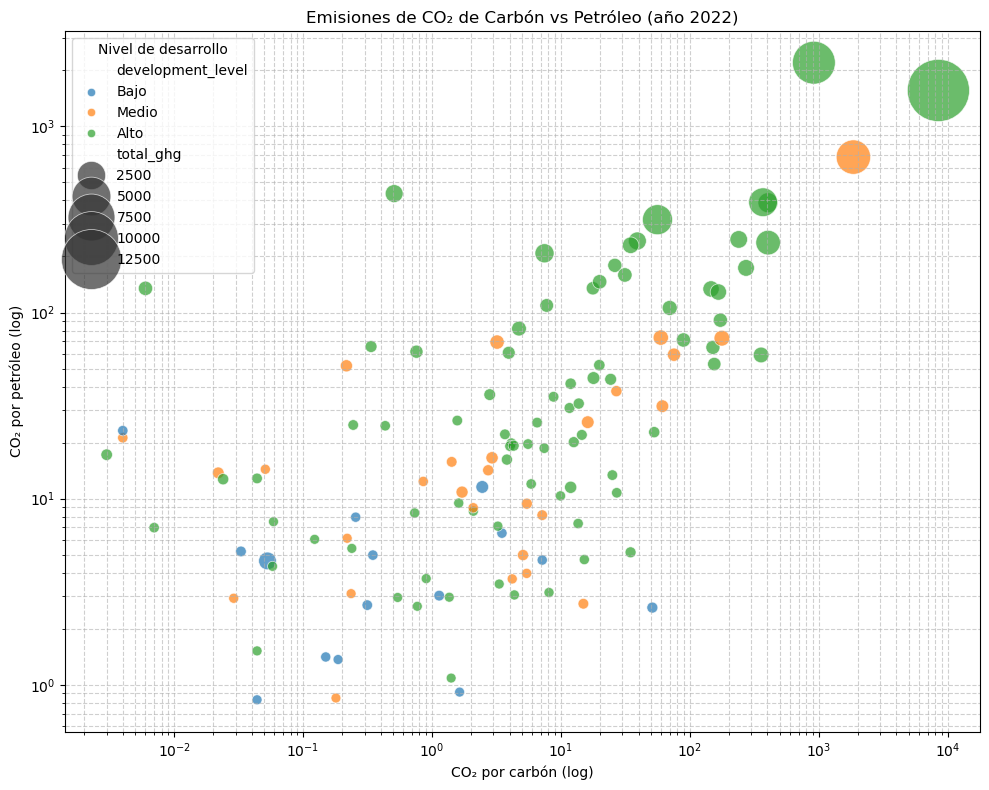

In [849]:


df_tmp = df_final[df_final['year'] == valid_year]
print('Valores negativos o cero:')
print(df_tmp[['coal_co2', 'oil_co2']] )
print((df_tmp[['coal_co2', 'oil_co2']] <= 0).sum())
print('---')

df_plot = df_final[
    (df_final['year'] == valid_year) &
    (df_final['coal_co2'] > 0) &
    (df_final['oil_co2'] > 0) &
    (df_final['total_ghg'] > 0)
]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_plot,
    x='coal_co2',
    y='oil_co2',
    hue='development_level',
    size='total_ghg',
    sizes=(50, 2000),
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')
plt.title(f'Emisiones de CO₂ de Carbón vs Petróleo (año {valid_year})')
plt.xlabel('CO₂ por carbón (log)')
plt.ylabel('CO₂ por petróleo (log)')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend(title='Nivel de desarrollo')
plt.tight_layout()
plt.show()

#df_plot['development_level'].value_counts(dropna=False)


El análisis de hizo con los datos del 2022 porque 2023 y 2024 no tenían datos.
Se observa una tendencia positiva, los países que emiten mucho CO2 por carbón tienden también a emitir mucho CO2 por petróleo. Los países de bajo desarrollo se concentran en la región de bajas emisiones de ambos combustibles, esto es esperado debido a una menor industrialización y consumo energético total.

Los países de desarrollo medio tienen una mayor dispersión, ocupan un rango más amplio de emisiones, desde un consumo moderado hasta perfiles que dependen fuertemente de algún combustible o ambos; esperado de economías en desarrollo.

Por su parte, los países de alto desarrollo muestran perfiles heterogéneos, desde economías con emisiones pequeñas hasta grandes emisores globales. La mayoría se concentra en las regiones de emisiones medias a altas, algunas tienen preferencia por el carbón, otros por el petróleo o ambas.

Los puntos más grandes encontrados en la parte superior derecha, asociados a emisiones altas de ambos; confirma que las emisiones de GHG total están fuertemente ligado al uso intensivo de combustibles fósiles.

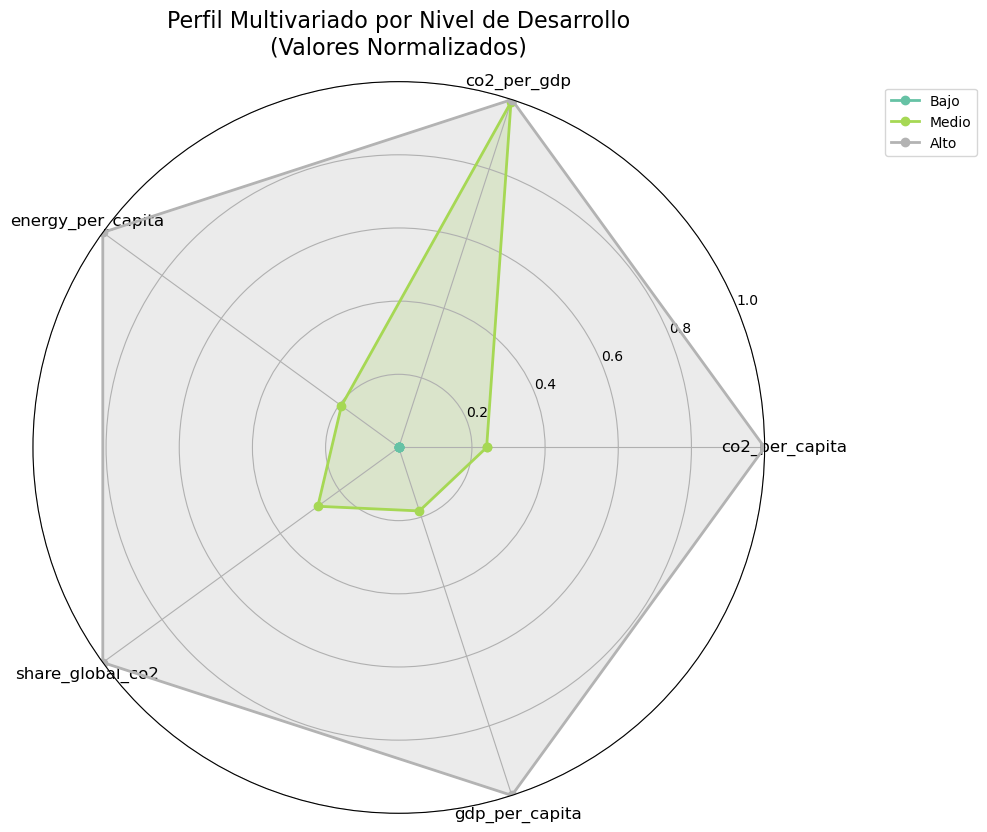

In [850]:
def create_radar_chart(df, category_col='development_level'):
    """
    Crea radar chart para comparar perfiles por categoría
    """
    # Variables para radar (seleccionar las más importantes)
    radar_vars = ['co2_per_capita', 'co2_per_gdp', 'energy_per_capita',
                  'share_global_co2', 'gdp_per_capita']

    # Calcular GDP per cápita si no existe
    if 'gdp_per_capita' not in df.columns:
        df['gdp_per_capita'] = df['gdp'] / df['population']

    # Agrupar por categoría y calcular medias, añadiendo observed=False para evitar el FutureWarning
    grouped = df.groupby(category_col, observed=False)[radar_vars].mean()

    # Normalizar para radar chart (0-1)
    normalized = (grouped - grouped.min()) / (grouped.max() - grouped.min())

    # Ángulos para cada variable
    angles = np.linspace(0, 2 * np.pi, len(radar_vars), endpoint=False).tolist()
    angles += angles[:1]  # Cerrar el círculo

    # Crear figura
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

    # Colores para cada categoría
    colors = plt.cm.Set2(np.linspace(0, 1, len(normalized)))

    # Plot para cada categoría
    for idx, (category, row) in enumerate(normalized.iterrows()):
        values = row.values.tolist()
        values += values[:1]  # Cerrar el círculo

        ax.plot(angles, values, 'o-', linewidth=2, label=category, color=colors[idx])
        ax.fill(angles, values, alpha=0.25, color=colors[idx])

    # Configurar
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_vars, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_title('Perfil Multivariado por Nivel de Desarrollo\n(Valores Normalizados)',
                 fontsize=16, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.tight_layout()

    return fig

# Crear radar chart
radar_fig = create_radar_chart(df_final, 'development_level')
plt.show()

Los países con nivel de desarrollo bajo son solamente un punto en el centro de la gráfica, porque tienen los valores más bajos en todas las métricas.
Los países con nivel de desarrollo medio tienen los picos más cerca del centro que los de nivel alto, indicando que sus valores promedio están en un punto intermedio a excepción de co2_per_gdp que tiene el valor más alto; coincide con lo observado en la gráfica anterior, donde se observaban niveles medios a altos en el consumo de CO2.
Los países con nivel de desarrollo alto tienen picos en los valores más altos, es decir, en promedio, tienen los valores más altos en CO2 per cápita, energía per cápita, PIB per cápita y en su contribución global de CO2.

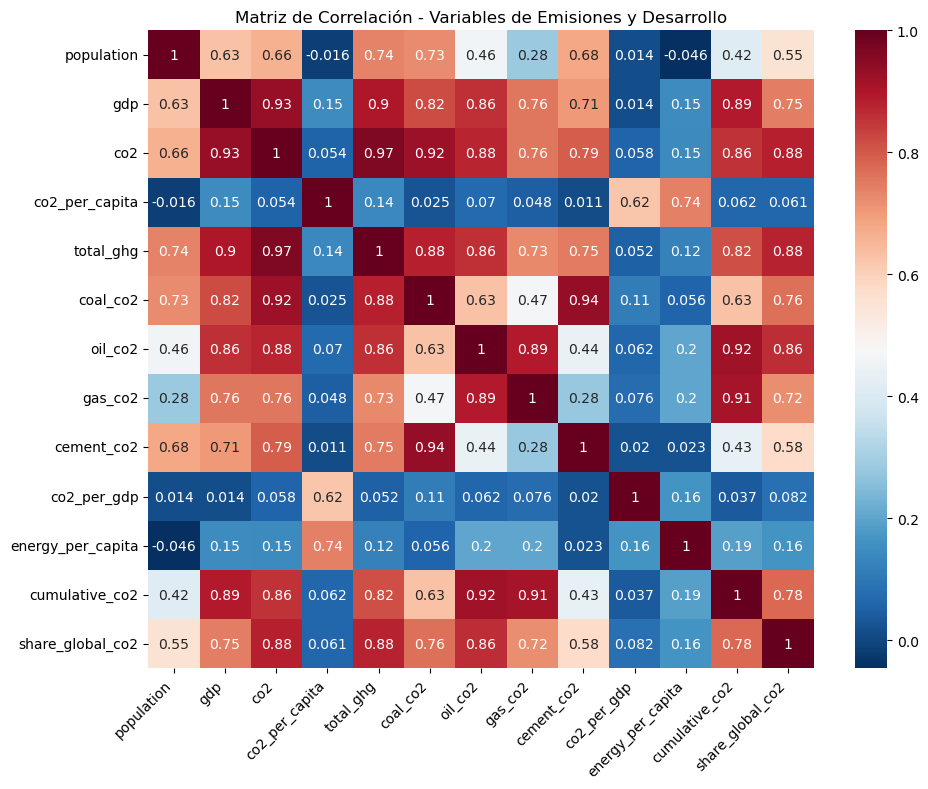

In [872]:
correlation_cols = ['population', 'gdp', 'co2', 'co2_per_capita',
                    'total_ghg', 'coal_co2', 'oil_co2', 'gas_co2',
                    'cement_co2', 'co2_per_gdp', 'energy_per_capita',
                    'cumulative_co2', 'share_global_co2', ]

corr_matrix = df_final[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r')

plt.title('Matriz de Correlación - Variables de Emisiones y Desarrollo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [873]:
corr_matrix.abs().sort_values(by="co2", ascending=False)


,population,gdp,co2,co2_per_capita,total_ghg,coal_co2,oil_co2,gas_co2,cement_co2,co2_per_gdp,energy_per_capita,cumulative_co2,share_global_co2
co2,0.661670,0.931431,1.000000,0.054050,0.965072,0.923379,0.876198,0.757433,0.793574,0.058354,0.145650,0.855372,0.884711
total_ghg,0.737367,0.900036,0.965072,0.141323,1.000000,0.884891,0.859385,0.729854,0.750085,0.052123,0.122744,0.815327,0.879855
gdp,0.629440,1.000000,0.931431,0.149203,0.900036,0.818795,0.857769,0.757889,0.705127,0.013998,0.147090,0.890424,0.746001
coal_co2,0.725126,0.818795,0.923379,0.024797,0.884891,1.000000,0.632035,0.467289,0.935062,0.111215,0.056419,0.632101,0.763916
share_global_co2,0.554387,0.746001,0.884711,0.061271,0.879855,0.763916,0.863438,0.722061,0.577868,0.081845,0.163143,0.775739,1.000000
oil_co2,0.456850,0.857769,0.876198,0.070032,0.859385,0.632035,1.000000,0.893282,0.442185,0.062498,0.201298,0.919942,0.863438
cumulative_co2,0.415639,0.890424,0.855372,0.061865,0.815327,0.632101,0.919942,0.910812,0.433384,0.037358,0.189188,1.000000,0.775739
cement_co2,0.679953,0.705127,0.793574,0.010615,0.750085,0.935062,0.442185,0.280440,1.000000,0.019723,0.022677,0.433384,0.577868
gas_co2,0.281348,0.757889,0.757433,0.047770,0.729854,0.467289,0.893282,1.000000,0.280440,0.075702,0.199320,0.910812,0.722061
population,1.000000,0.629440,0.661670,0.016156,0.737367,0.725126,0.456850,0.281348,0.679953,0.013682,0.045921,0.415639,0.554387


Debido a que existe una **alta multicolinealidad** entre nuestras variables predictoras como (gdp, population, co2, total_ghg, coal_co2, oil_co2, gas_co2, cement_co2, co2_per_gdp, energy_per_capita, cumulative_co2, share_global_co2), como se ve en la matriz de correlación, donde tienen valores cercanos a 1 en la variable 'co2'.

La presencia de multicolinealidad dificulta la interpretación individual de los coeficientes del modelo en RLM. Sin embargo, PCA se utilizó de manera exploratoria para entender la estructura interna de los datos, si bien ayuda a generar componentes no correlacionados se pierde la interpretación directa de las variables originales; por lo que se empleó para realizar clustering solamente. Mientras que Regresión se realizó utilizando las variables originales seleccionadas.

### Plots multivariados

Seleccionamos las columnas "population", "gdp", "co2", "coal_co2", "oil_co2", "gas_co2" y los países "China", "India", "United States", "Russia", "Germany", "Mexico", "Brazil", "South Africa" para hacer una comparativa con plots multivaridos. Para esto hacemos un Dataframe unicamente con estos datos.

In [851]:
vars_multi = ["population", "gdp", "co2",
    "coal_co2", "oil_co2", "gas_co2"]

df_multi = df[["country"] + vars_multi].dropna()

countries_sel = ["China", "India", "United States",
    "Russia", "Germany", "Mexico",
    "Brazil", "South Africa"]

df_multi = df_multi[df_multi["country"].isin(countries_sel)]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_multi[vars_multi])

df_scaled = pd.DataFrame(X_scaled, columns=vars_multi)
df_scaled["country"] = df_multi["country"].values

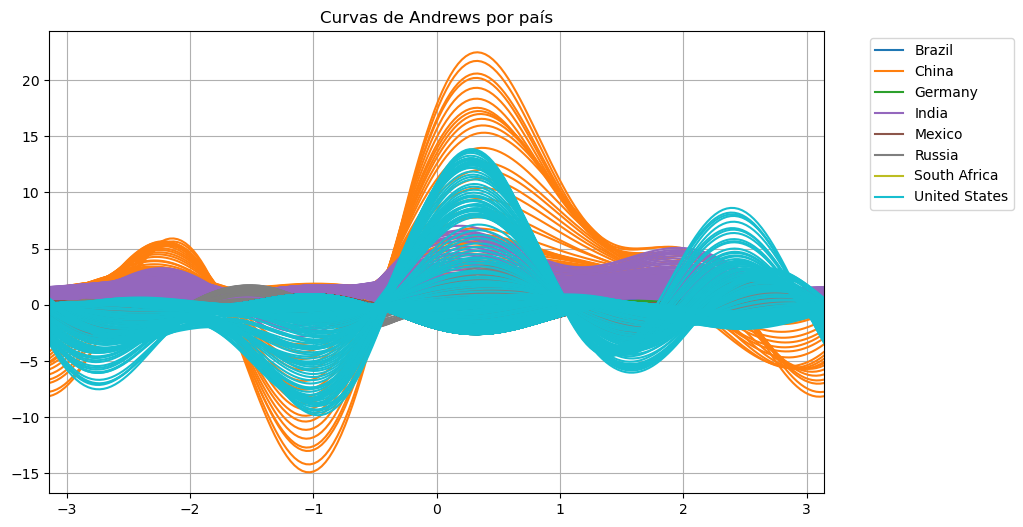

In [852]:
plt.figure(figsize=(10,6))
andrews_curves(df_scaled, "country", colormap=plt.cm.tab10)
plt.title("Curvas de Andrews por país")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Las curvas representan cada país como una función basada en todas sus variables. Países con perfiles similares tendrán curvas que se superponen o con patrones parecidos.

1. Estados Unidos (azul claro) y China (naranja)
Perfiles únicos y extremos: países con valores más altos en algunas variables, indicando fuerte variabilidad entre sus características, dominan variables con valores positivos. Tienen picos muy marcados y claramente son distintas al resto, es decir, tienen valores extremos en varias variables. 

2. Grupos similares: India y Rusia muestran curvas muy similares, esto indica que tienen estructuras económicas/sociales parecidas, aunque sus perfiles son menos extremos comparados con EE.UU. Sugieren economías o emisiones altas pero con diferentes estructuras. 

3. Sudáfrica, Brasil, Alemania y México (líneas verde claro y cafe)
Sudáfrica tiene un perfil ligeramente más alto que México, ambos muestran cierta similitud con el grupo principal. Son curvas más cercanas entre si con menor variabilidad, estos parecen agrupamientos naturales y más densos. 

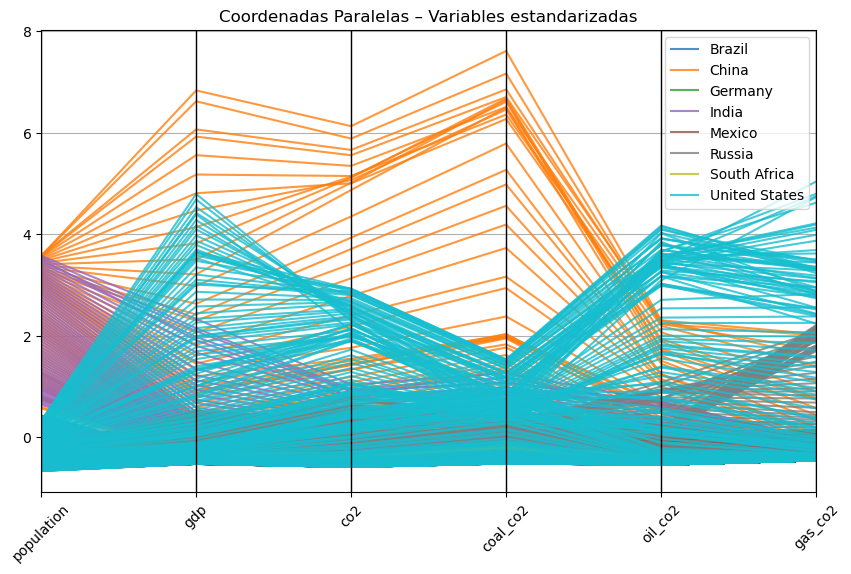

In [853]:
plt.figure(figsize=(10,6))
parallel_coordinates(df_scaled, class_column="country", alpha=0.8, colormap=plt.cm.tab10)
plt.title("Coordenadas Paralelas – Variables estandarizadas")
plt.xticks(rotation=45)
plt.show()

Evidencia una fuerte multicolinealidad entre los indicadores de emisiones y actividad económica. Se observan patrones similares entre las variables gdp, co2 al tener las mayores dispersiones; vemos que dominan la varianza del dataset. Las emisiones por tipo de combustible siguen patrones similares, es decir, hay correlación entre ellas. Asi mismo, países como China y Estados Unidos tienen  perfiles extremos claramente diferenciados del resto. 

## Análisis de Componentes Principales (PCA)

### 1. Imputar valores nulos para variables predictoras


In [775]:
df_pca = df_final.copy()

In [776]:
df_pca['population'] =  df_pca['population'].fillna(df_pca['population'].median())

In [777]:
imputer = IterativeImputer(max_iter=10, random_state=42)
predictoras = ['population', 'gdp', 'co2', 'co2_per_capita',
                    'total_ghg', 'coal_co2', 'oil_co2', 'gas_co2',
                    'cement_co2', 'co2_per_gdp', 'energy_per_capita',
                    'cumulative_co2', 'share_global_co2']
df_pca[predictoras] = imputer.fit_transform(df_pca[predictoras])


### 2. Escalar variables numéricas

In [778]:
X = df_pca[predictoras]

pca_scaler = StandardScaler()
X_scaled = pca_scaler.fit_transform(X)

### 3. Aplicar PCA

In [779]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

### 4. Varianza explicada

In [780]:
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

for i, (ev, cv) in enumerate(zip(explained_var, cum_var), 1):
    print(f"PC{i}: Var = {ev:.3f}, Acumulada = {cv:.3f}")

PC1: Var = 0.593, Acumulada = 0.593
PC2: Var = 0.213, Acumulada = 0.805
PC3: Var = 0.105, Acumulada = 0.911
PC4: Var = 0.030, Acumulada = 0.940
PC5: Var = 0.023, Acumulada = 0.964
PC6: Var = 0.016, Acumulada = 0.980
PC7: Var = 0.007, Acumulada = 0.987
PC8: Var = 0.005, Acumulada = 0.992
PC9: Var = 0.003, Acumulada = 0.995
PC10: Var = 0.002, Acumulada = 0.998
PC11: Var = 0.001, Acumulada = 0.999
PC12: Var = 0.001, Acumulada = 1.000
PC13: Var = 0.000, Acumulada = 1.000


Vemos que PC1 y PC2 explican el 80.5% de la variabilidad de los datos y PC3 el 10.5%. Los tres juntos explican el 91.1% de la variabilidad total. A partir de PC4 cada componente aporta muy poco, por lo que no tendría sentido considerarlos.

In [809]:
A = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(predictoras))],
    index=predictoras).round(3)

A

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
population,0.249,-0.058,0.424,0.812,-0.140,-0.073,0.088,-0.095,-0.151,-0.154,0.005,0.082,0.002
gdp,0.342,-0.013,-0.037,-0.035,-0.484,0.084,-0.358,0.145,-0.297,0.407,-0.048,-0.483,-0.004
co2,0.357,-0.013,0.039,-0.156,0.045,0.016,0.045,0.003,0.103,-0.347,0.002,-0.178,0.824
co2_per_capita,0.027,0.595,0.041,0.004,-0.033,-0.099,-0.021,-0.003,0.009,0.021,0.794,-0.037,-0.001
total_ghg,0.351,-0.031,0.060,0.111,0.106,-0.016,0.110,0.221,0.727,0.501,-0.003,0.088,-0.008
coal_co2,0.320,-0.031,0.340,-0.283,0.081,0.011,-0.009,-0.325,0.243,-0.367,-0.013,-0.401,-0.483
oil_co2,0.325,0.013,-0.316,0.089,0.120,0.006,-0.318,0.610,-0.012,-0.452,0.014,0.174,-0.252
gas_co2,0.286,0.020,-0.470,0.026,-0.146,0.014,0.781,-0.014,-0.163,-0.026,0.012,-0.122,-0.149
cement_co2,0.270,-0.044,0.495,-0.452,-0.123,0.012,0.205,0.220,-0.317,0.104,0.028,0.507,-0.039
co2_per_gdp,0.013,0.559,0.090,0.074,0.134,0.740,0.045,0.019,-0.027,0.011,-0.325,0.008,-0.001


A partir de la tabla podemos interpretar lo siguiente:

Vemos que el primer componente principal explica el 59.3% de la variabilidad total. Las variables más relacionadas con PC1 son: co2 → 0.357; total_ghg → 0.351; oil_co2, coal_co2, gas_co2 → ~0.30; gdp → 0.342 y share_global_co2 → 0.322. Estos miden el tamaño absoluto del impacto climático de un país, es decir, el volumen total.

El segundo componente explica el 21.3% de la variabilidad, está asociado con: co2_per_capita → 0.595; energy_per_capita → 0.570 y co2_per_gdp → 0.559. Este componente nos dice que tan "intensivo" es en el uso de la energía y en la generación de CO2 independientemente de su tamaño. En otras palabras, PC2 nos ayuda a diferenciar entre países que tienen una gran huella individual.

PC3 asociado a: cement_co2 → 0.495; coal_co2 → 0.340; population → 0.424; gas_co2 → –0.470; oil_co2 → –0.316 y cumulative_co2 → –0.340. Explica el 10.5% de la variabilidad de los datos. Estos explican de qué fuentes proviene el CO2:

- Valores positivos → economías dependientes de cemento y carbón
- Valores negativos → economías más dependientes de gas y petróleo

Podemos interpretarlos así:
1.  Escala de emisiones y actividad económica (PC1)
2.  Intensidad de carbono y consumo energético per cápita (PC2)
3.  Composición de matriz energética (PC3)

Estos componentes se utilizarán posteriormente para PCA.

## Regresión Lineal Múltiple (RLM)


Vamos a definir la variable a predecir "y" como 'co2' que son las emisiones de carbono y las variables predictoras serán: 'population', 'oil_co2', 'cement_co2' y 'gas_co2'. Se eligieron de esta manera por su relevancia teórica en comparación con las demás variables, además de su alta correlación con la variable "y" pero con correlación moderada entre ellas. Estas permiten modelar el impacto por sectores productivos y la demanda energética, por lo tanto son buenos estimadores.

### 1. Quitar los renglones vacíos de co2 (variable a predecir)

In [782]:
df_rlm = df_pca.copy()
df_rlm.dropna(subset=['co2'], inplace=True)

### 2. Definir variable objetivo y variables predictoras

In [783]:
# Variable objetivo (dependiente)
y = df_rlm['co2']

# Variables independientes (predictoras)
X = df_rlm[['population', 'oil_co2', 'cement_co2', 'gas_co2']]

X.shape, y.shape

((16425, 4), (16425,))

### 3. Dividir los datos en conjuntos de entrenamiento(80%) y prueba(20%)

In [784]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape,X_test.shape

((13140, 4), (3285, 4))

### 4. Escalar variables

In [785]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. Entrenar el modelo

In [786]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 6. Realizar predicciones

In [787]:
y_pred = model.predict(X_test_scaled)

### 7. Evaluar el modelo

In [788]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 4758.34
R-squared (R2): 0.97
Mean Absolute Error (MAE): 27.34


El R Squared de 0.97 es bastante alto, significa que el modelo explica el 97% de la variabilidad de las emisiones de CO2 basándose en las variables predictoras que utilizamos, es decir, refleja bien la estructura de los datos. Este resultado tiene sentido ya que 'oil_co2', 'cement_co2' y 'gas_co2' son componentes directos de las emisiones de CO2 total.

El Mean Absolute Error (MAE) nos dice (en las mismas unidades que CO2) cuánto se equivoca en promedio el modelo, en este caso un MAE de 27.34 quiere decir que en promedio el modelo se equivoca en unos 27.34 millones de toneladas de CO2. Recordemos que los rangos de emisiones van desde países que producen muy pocas toneladas de CO2 hasta países que producen miles de toneladas de CO2.

El Mean Squared Error (MSE) es de 4758.34. En este caso considerando las otras dos métricas, un R2 alto y MAE relativamente bajo, sugiere que el modelo es preciso.



### 8. Análisis de los coeficientes

In [789]:
feature_names = X.columns
coefficients = model.coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("Coeficientes del modelo de Regresión Lineal Múltiple:")
coef_df

Coeficientes del modelo de Regresión Lineal Múltiple:


,Feature,Coefficient
2,cement_co2,269.795397
1,oil_co2,255.536800
3,gas_co2,93.222446
0,population,30.126637


Los atributos cement_co2 (269.79), oil_co2 (255.53), gas_co2 (93.22) son los predictores más fuertes y positivos. Como era de esperar, un aumento en las emisiones de CO2 provenientes del cemento, el petróleo o el gas se traduce directamente en un aumento de las emisiones totales de CO2. El atributo population (30.12) tiene un coeficiente positivo pero menor que las fuentes de CO2, indica que, una desviación estándar en la población se asocia con un aumento de 30.13 unidades en las emisiones totales de CO2.

Este modelo al incluir directamente las principales fuentes de emisión de CO2 (oil_co2, cement_co2, gas_co2), junto con la población, logra un rendimiento sobresaliente.

## Clustering por país

Anteriormente realizamos PCA sobre nuestros datos debido a la alta correlación y redundancia de las variables originales y encontramos 3 componentes principales que explicaban el mayor porcentaje de variabilidad de nuestros datos; ideal para clustering. Dado que los métodos de clustering se basan en distancias, la multicolinealidad puede afectar en la formación de los grupos, PCA permite transformar en un conjunto reducido de componentes no correlacionados que conserven la variabilidad original de los datos.

Graficamos para ver la estructura de nuestros datos.

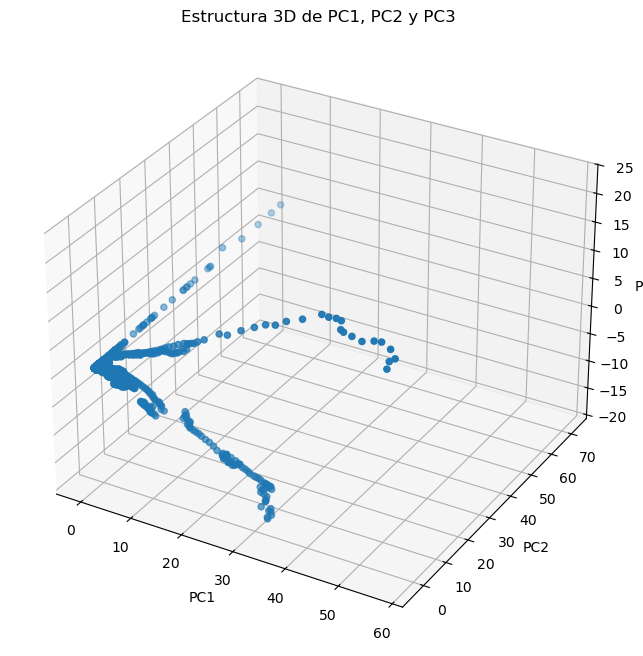

In [790]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Estructura 3D de PC1, PC2 y PC3')
plt.show()

In [791]:
# Crear un DataFrame temporal con los componentes principales y las variables
df_pca_interactive = df_pca.copy()
df_pca_interactive['PC1'] = X_pca[:, 0]
df_pca_interactive['PC2'] = X_pca[:, 1]
df_pca_interactive['PC3'] = X_pca[:, 2]

fig = px.scatter_3d(df_pca_interactive,
                    x='PC1',
                    y='PC2',
                    z='PC3',
                    color='development_level',
                    hover_name='country',
                    hover_data=['year', 'co2', 'gdp'], # Información adicional
                    title='Estructura 3D de PC1, PC2 y PC3')

fig.update_layout(scene = dict(
                    xaxis_title='PC1 ', #(Escala Económica y Emisiones Absolutas)
                    yaxis_title='PC2 ', #(Intensidad Per Cápita)
                    zaxis_title='PC3 ')) #(Composición Matriz Energética y Demografía)

fig.show()

De acuerdo con el gráfico 3D los datos presentan una estructura ramificada, alargada y con concentraciones locales. Indicando países con perfiles claramente distintos y una estructura interna definida.

A lo largo del eje PC1 la mayoría de países están cerca del origen y algunos se separan mucho.

- Izquierda → países con un impacto total
- Derecha → grandes emisores globales

PC2 presenta una separación vertical clara; hay países que consumen mucha energía per cápita y países con menor intensidad energética.

PC3 crea ramificaciones, muestra que países con emisiones similares pueden tener perfiles de emisión muy diferentes según sus fuentes de energía.

Este gráfico revela que la estructura de las primeras 3 componentes principales es compleja y no aleatoria, podemos ver una separción natural de los datos y potenciales grupos de países.   


Para este caso es óptimo usar clustering jerárquico y DB-Scan; ya que estos no asumen una forma como K-Means que asume formas esféricas de tamaño similar. Puesto que nuestros datos son ramificados, alargados y con outliers DB-Scan es capaz de encontrar clústers de formas irregulares, además de que los forma de acuerdo a la densidad de los puntos (útil en este caso) y trata outliers de manera óptima.

Por su parte el clústering jerárquico tampoco asume una forma esférica ni necesita un número de clústers de antemano, sino que el dendrograma permite ver las agrupaciones y estas las relaciones y subgrupos dentro de los datos.

Ambos métodos se adaptan a la estructura no esférica de los datos; nos permitirán obtener clústers más acertados y naturales.

### 1. Clústering Jerárquico 

Vamos a tomar el último año disponible, 2022 para realizar el clústering, ya que en nuestros dataset hay observaciones a través del tiempo de países. Por lo tanto si hicéramos clústering con todas las observaciones quedarían muchos agrupados en uno solo o un solo clúster para un país. 

#### 1. Filtrar datos del último año disponible (2022)

In [792]:
df_year = df_pca[df_pca['year'] == 2024].copy()
print(f"Número de países en {2024}: {len(df_year)}")

# Aplicar el mismo escalado y PCA (pca_scaler de la sección PCA)
X_year = df_year[predictoras]
X_year_scaled = pca_scaler.transform(X_year)
X_pca_year = pca.transform(X_year_scaled)

Número de países en 2024: 219


#### 2. Método del codo

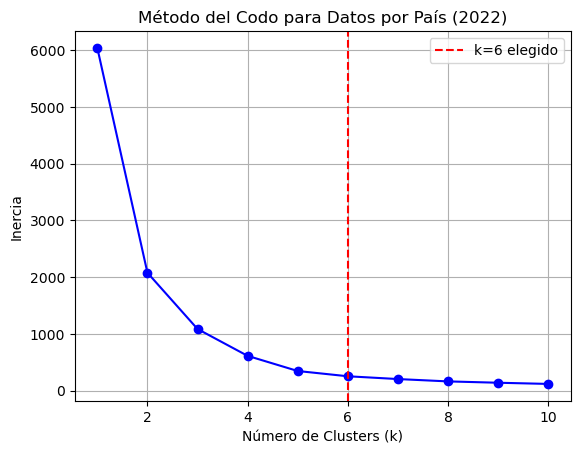

In [793]:
max_k = 10
inertias = []

for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_year)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, max_k + 1), inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Datos por País (2022)')
plt.grid(True)
plt.axvline(x=6, color='r', linestyle='--', label='k=6 elegido')
plt.legend()
plt.show()

Vemos que el codo está en k=4

#### 3. Silhouette Score

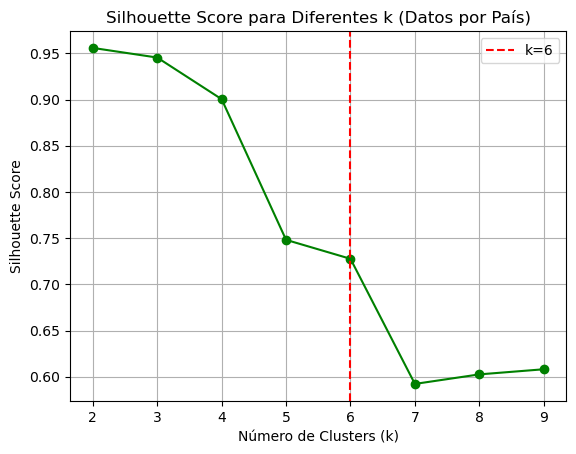

In [794]:
max_k = 9
sil_scores = []
for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_year)
    sil = silhouette_score(X_pca_year, labels)
    sil_scores.append(sil)

plt.plot(range(2, max_k + 1), sil_scores, 'go-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para Diferentes k (Datos por País)')
plt.grid(True)
plt.axvline(x=6, color='r', linestyle='--', label='k=6')
plt.legend()
plt.show()

#### 5. Aplicamos clústering

In [795]:
jerarquico_year = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_year = jerarquico_year.fit_predict(X_pca_year)

# Agregar clusters al DataFrame
df_cluster_year = df_year.copy()
df_cluster_year['cluster'] = labels_year

#### 4. Visualización de clusters


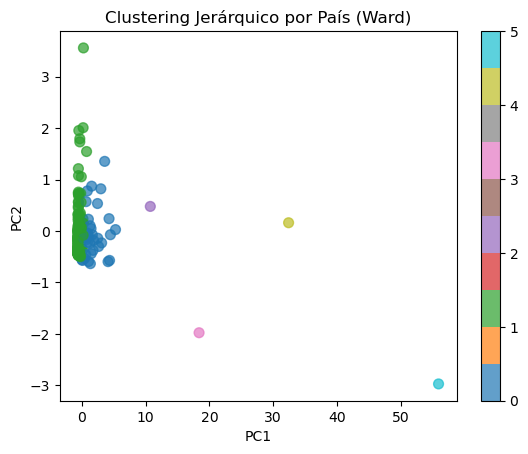

In [811]:
fig, ax = plt.subplots()
scatter = ax.scatter(X_pca_year[:, 0], X_pca_year[:, 1], c=labels_year, cmap='tab10', alpha=0.7, s=50)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Clustering Jerárquico por País (Ward)')
plt.colorbar(scatter)
plt.show()

#### 5. Países por clúster y características promedio

In [797]:
cluster_summary_year = df_cluster_year.groupby('cluster')[predictoras].mean()
display(cluster_summary_year.round(2))

,population,gdp,co2,co2_per_capita,total_ghg,coal_co2,oil_co2,gas_co2,cement_co2,co2_per_gdp,energy_per_capita,cumulative_co2,share_global_co2
cluster,,,,,,,,,,,,,
0,9.139236e+07,1.279466e+12,348.46,5.79,590.40,94.46,134.72,97.01,13.87,0.32,29157.34,20431.97,0.90
1,9.365906e+06,9.350294e+10,20.42,4.32,44.26,-2.29,9.38,11.75,0.80,0.28,26054.86,1173.48,0.06
2,1.448204e+08,4.556178e+12,1780.52,12.30,2729.24,375.65,437.89,857.67,25.22,0.27,62485.31,122808.23,4.61
3,1.450936e+09,7.867677e+12,3193.48,2.20,4262.41,2108.03,747.33,149.35,185.97,0.16,7812.93,66072.53,8.27
4,3.454266e+08,1.860392e+13,4904.12,14.20,6054.31,732.89,2189.16,1748.14,37.27,-0.79,76799.57,434866.56,12.70
5,1.419321e+09,1.757144e+13,12289.04,8.66,14107.01,8886.02,1705.39,889.41,617.75,1.09,34514.46,285087.03,31.84


In [798]:
print("\nPaíses en cada cluster:")
for i in sorted(df_cluster_year['cluster'].unique()):
    cluster_countries = df_cluster_year[df_cluster_year['cluster'] == i]['country'].tolist()
    print(f"\nCluster {i} ({len(cluster_countries)} países): {', '.join(cluster_countries[:10])}{'...' if len(cluster_countries) > 10 else ''}")


Países en cada cluster:

Cluster 0 (34 países): Algeria, Argentina, Australia, Bangladesh, Brazil, Canada, Democratic Republic of Congo, Egypt, Ethiopia, France...

Cluster 1 (181 países): Afghanistan, Albania, Andorra, Angola, Anguilla, Antarctica, Antigua and Barbuda, Armenia, Aruba, Austria...

Cluster 2 (1 países): Russia

Cluster 3 (1 países): India

Cluster 4 (1 países): United States

Cluster 5 (1 países): China


#### 5. Silhouette Score 

In [799]:
sil_score = silhouette_score(X_pca_year, labels_year)
print(f"Silhouette Score: {sil_score:.3f}")

# Valores cercanos a 1 indican clusters bien separados, negativos mal asignados.

Silhouette Score: 0.619


#### 6. Dendrograma y Clústers en espacio PCA

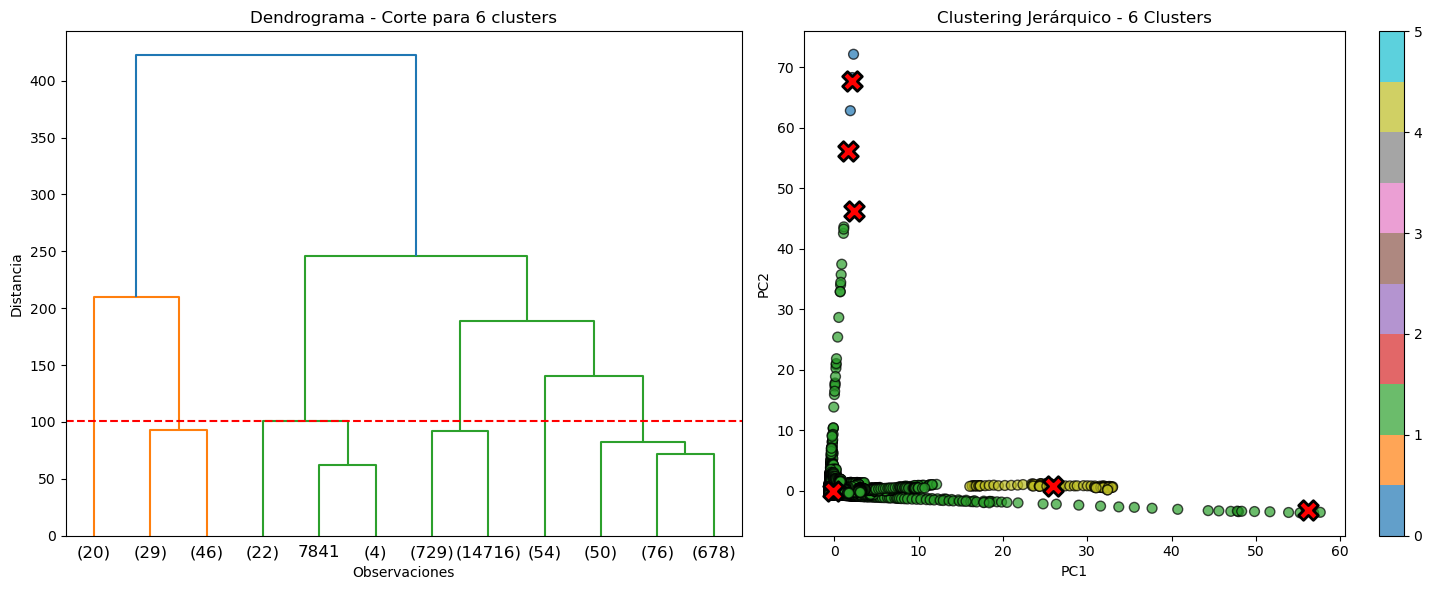

In [800]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


# Dendrograma con corte
Z = linkage(X_pca, method='ward', metric='euclidean')
k_optimo = 6

ax1.set_title(f'Dendrograma - Corte para {k_optimo} clusters')
dendrogram(Z, truncate_mode='lastp', p=12, ax=ax1)
ax1.axhline(y=Z[-k_optimo, 2], color='r', linestyle='--')
ax1.set_xlabel('Observaciones')
ax1.set_ylabel('Distancia')

# Clusters en espacio PCA
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels_sklearn, cmap='tab10',
                      alpha=0.7, s=50, edgecolor='k')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title(f'Clustering Jerárquico - {k_optimo} Clusters')

# Añadir centroides (para interpretación)
for cluster_id in range(k_optimo):
    cluster_points = X_pca[labels_sklearn == cluster_id]
    centroid = cluster_points.mean(axis=0)
    ax2.scatter(centroid[0], centroid[1],
                color='red', s=200, marker='X',
                edgecolor='black', linewidth=2)

plt.colorbar(scatter, ax=ax2)
plt.tight_layout()
plt.show()

En el dendrograma con encadenamiento 'ward', se hizo el corte en 6 clusters, lo que resulta en grupos más equilibrados y separados, adecuados para la estructura de los datos. En el gráfico de dispersión, los clusters aparecen claramente diferenciados:

- **Cluster 0** (pequeños emisores, 34 países): Agrupa países con emisiones absolutas moderadas y media intensidad, como la mayoría de los países en desarrollo o pequeños, ubicados en la izquierda del gráfico (bajo PC1).

- **Cluster 1** (emisores medios, 181 países): El cluster más grande integradao por la mayoria de píses con emisiones moderadas como Brasil, Canadá, Alemania, Indonesia, Irán, Japón, Arabia Saudita, Reino Unido, etc., con perfiles más bajos o intermedios en escala e intensidad.Lo que indica un impacto climático total bajo. 

- **Cluster 2** (Rusia, 1 país): Un cluster separado para Rusia, con altas emisiones absolutas pero perfil específico en composición energética.

- **Cluster 3** (India, 1 país): Un cluster para India, con muy altas emisiones absolutas y alta intensidad per cápita.

- **Cluster 4** (Estados Unidos, 1 país): Un cluster separado para EE.UU., con perfil alto tanto en intensidad como en escala.

- **Cluster 5** (China, 1 país): Un cluster para China, el mayor emisor global, ubicado en la derecha extrema del gráfico (alto PC1 y PC2).

Los centroides marcan los promedios de cada grupo.

PC1 representa la 'Escala de emisiones y actividad económica' (volumen total). Los clústeres más a la derecha en este eje contendrán países con mayores emisiones absolutas y mayor actividad económica. Mientras que a la izquierda estarán los de menor impacto total.

PC2 representa la 'Intensidad de carbono y consumo energético per cápita'. Los clústeres más arriba en este eje agruparán países con mayor intensidad per cápita, y los de abajo, con menor intensidad.

### 2. DB-Scan

#### 1. Definir función objetivo para optuna

In [801]:
def objective(trial):
    eps = trial.suggest_float("eps", 0.5, 5.0)  
    min_samples = trial.suggest_int("min_samples", 1, 5)  
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_pca_year)

    # Excluir ruido
    #unique_labels = set(labels)
    #if len(unique_labels) <= 1 or unique_labels == {-1}:
    #    return -1.0

    # Silhouette solo con puntos no ruido
    #mask = labels != -1
    #if mask.sum() < 2:
    #    return -1.0

    mask = labels != -1

    n_clusters = len(set(labels[mask])) 

    if n_clusters < 2 or n_clusters >10: 
        return -1.0

    score = silhouette_score(X_pca_year[mask], labels[mask])
    return score


#### 2. Ejecutar optuna

In [802]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

study.best_params, study.best_value

[I 2026-01-04 15:40:54,081] A new study created in memory with name: no-name-98056009-1a71-40ea-97d1-3202c9d313eb
[I 2026-01-04 15:40:54,084] Trial 0 finished with value: -1.0 and parameters: {'eps': 3.1097086855431115, 'min_samples': 5}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,085] Trial 1 finished with value: -1.0 and parameters: {'eps': 1.0156713847917387, 'min_samples': 3}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,087] Trial 2 finished with value: -1.0 and parameters: {'eps': 3.2513584278418524, 'min_samples': 5}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,089] Trial 3 finished with value: -1.0 and parameters: {'eps': 4.17140067984614, 'min_samples': 3}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,090] Trial 4 finished with value: -1.0 and parameters: {'eps': 2.6838216901526812, 'min_samples': 5}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,092] Trial 5 finished with value: -1.0 and parameters: {'eps': 2.78926

({'eps': 4.837083301877202, 'min_samples': 1}, 0.8725253268534399)

#### 3. DB-Scan con los mejores parámetros 

In [803]:
best_eps = study.best_params["eps"]
best_min_samples = study.best_params["min_samples"]

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples)

labels = dbscan.fit_predict(X_pca_year)

df_cluster_year['cluster_dbscan'] = labels

#### 4. Visulización de clústers

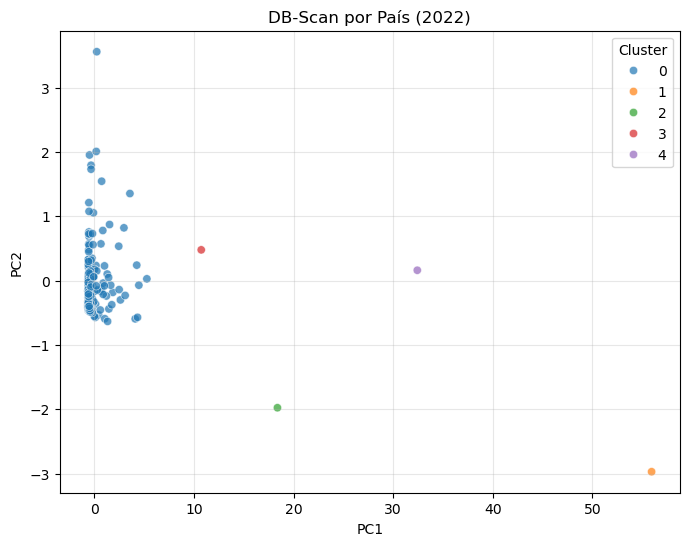

In [804]:
fig, ax = plt.subplots(figsize=(8, 6))
temp_df_year = pd.DataFrame({
    'PC1': X_pca_year[:, 0],
    'PC2': X_pca_year[:, 1],
#    'PC3': X_pca_year[:, 2],
    'cluster': labels
})
sns.scatterplot(data=temp_df_year, x='PC1', y='PC2', hue='cluster', palette="tab10", alpha=0.7)
plt.title("DB-Scan por País (2022)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

#### 5. Análisis de clústers  

In [805]:
unique_labels_year, counts_year = np.unique(labels, return_counts=True)
print("Clusters encontrados por DB-Scan (2022):")
for label, count in zip(unique_labels_year, counts_year):
    if label == -1:
        print(f"Ruido: {count} países")
    else:
        print(f"Cluster {label}: {count} países")

# Países únicos
for label in unique_labels_year:
    if label == -1:
        cluster_countries = df_cluster_year[df_cluster_year['cluster_dbscan'] == label]['country'].unique()[:5].tolist()
        print(f"\nRuido (ejemplos): {', '.join(cluster_countries)}")
    else:
        cluster_countries = df_cluster_year[df_cluster_year['cluster_dbscan'] == label]['country'].unique()[:5].tolist()
        print(f"\nCluster {label} (ejemplos): {', '.join(cluster_countries)}")

Clusters encontrados por DB-Scan (2022):
Cluster 0: 215 países
Cluster 1: 1 países
Cluster 2: 1 países
Cluster 3: 1 países
Cluster 4: 1 países

Cluster 0 (ejemplos): Afghanistan, Albania, Algeria, Andorra, Angola

Cluster 1 (ejemplos): China

Cluster 2 (ejemplos): India

Cluster 3 (ejemplos): Russia

Cluster 4 (ejemplos): United States


#### Interpretación DB-Scan por País (2022)

Aplicando DB-Scan a los datos de 2022 por país (igual que el clustering jerárquico), muestra un cluster principal que agrupa a 215 países, los cuales comparten patrones similares en las variables analizadas con PCA. Está compuesto mayoritariamente por países con perfiles económicos, demográficos y de emisiones comparables.

Se identifican cuatro clusters individuales, cada uno formado por un solo país: China, India, Rusia y Estados Unidos: esto tiene sentido ya que son outliers y presentan niveles muy altos de emisiones, población, etc. 

Esto complementa el clustering jerárquico, confirmando la separación de grandes emisores como ruido/outliers.